In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout,Activation,BatchNormalization
from tensorflow.keras.regularizers import l2
dataset_path = "/content/drive/MyDrive/data_dechet/Data/Train"
dataset_path_test = "/content/drive/MyDrive/data_dechet/Data/Test"

print(os.listdir(dataset_path))

['plastic', 'metal']


In [ ]:
train_dir = '/content/drive/MyDrive/data_dechet/Data/Train'

In [ ]:
#ici on vas definir la tailler dees images
img_size=(300,300)
"""ici on vas faire la multication des images
a la sortie dans notre base de nous aurons 70000 images
en format jpg
"""
num_augmented_images = 100


In [ ]:
#ici on va faire du generateur d'augme,tation
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    brightness_range=(0.6, 1.4),
    horizontal_flip=True,
    fill_mode='nearest'
)
def augmenter_images(dataset_path, dossier):

    os.makedirs(dossier, exist_ok=True)

    for filename in os.listdir(dataset_path):

        if not filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue

        image_path = os.path.join(dataset_path, filename)

        img = load_img(image_path, target_size=image_size)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        i = 0

        for batch in datagen.flow(
            img_array,
            batch_size=1,
            save_to_dir=dossier,
            save_prefix="aug_" + filename.split('.')[0],
            save_format="jpg"
        ):
            i += 1
            if i >= num_augmented_images:
                break

# Chemins sur driver ou ces trouver le projet d'entre
train_dir = '/content/drive/MyDrive/data_dechet/Data/Train'
# Chemins sur driver ou ces trouver le projet d'sortie
train_output = '/content/drive/MyDrive/data_dechet/Data/Train'
# Lancement
augmenter_images(train_dir, train_output)
#on vas affiche une fois ces termine
print(' Multiplication terminée')

 Multiplication terminée


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(300, 300),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(300,300),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 2384 images belonging to 2 classes.
Found 594 images belonging to 2 classes.


In [ ]:
print(train_data.class_indices)
print(val_data.class_indices)

{'metal': 0, 'plastic': 1}
{'metal': 0, 'plastic': 1}


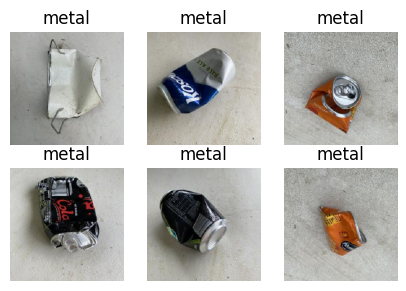

In [ ]:
# Prendre un batch d'images
images, labels = next(train_data)
plt.figure(figsize=(5,5))
for i in range(6):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[labels[i].argmax()])
    plt.axis('off')
plt.show()

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.3,
    brightness_range=(0.6, 1.4),
    horizontal_flip=True
)

In [ ]:
# ici on vas definir notre reseau
"""
nous un reseau de 4 couche avec 3 couche de convolution et 1 couche de pool nous avons 2 couche de dense avec 1 couche de dropout pour eviter le surapprentissage
nous avons mis le sequentiel a 3 pour RGB pour la couleurs de nos images nosu avosn definis la taille de nos images de 300*300 nosu avons utilise
la fonction d'activation relu et la fonction de perte categorical_crossentropy
"""
model = Sequential()

# premiere couche
model.add(Conv2D(32, kernel_size=(3,3), padding='same', input_shape=(300,300,3)))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=2))

# deuxime couche
model.add(Conv2D(32, kernel_size=(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=2))
# troisiseme couche
model.add(Conv2D(32, kernel_size=(3,3), padding='same'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=2))

model.add(Flatten())

model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.2))

model.add(Dense(32))
model.add(BatchNormalization())
model.add(Activation('relu'))


model.add(Dropout(0.5))

model.add(Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(
                               monitor='val_loss',
                               patience=2,
                               restore_best_weights=True)

In [ ]:
history=model.fit(
    train_data,
    epochs=8,
    batch_size=32,
    validation_data=val_data
)

Epoch 1/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 834s 11s/step - accuracy: 0.6925 - loss: 0.6317 - val_accuracy: 0.1616 - val_loss: 0.8810
Epoch 2/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 229ms/step - accuracy: 0.7857 - loss: 0.4772 - val_accuracy: 0.1616 - val_loss: 1.3133
Epoch 3/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 238ms/step - accuracy: 0.8142 - loss: 0.4194 - val_accuracy: 0.1852 - val_loss: 1.3198
Epoch 4/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 234ms/step - accuracy: 0.8721 - loss: 0.3364 - val_accuracy: 0.2492 - val_loss: 1.1738
Epoch 5/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.8930 - loss: 0.2956 - val_accuracy: 0.2912 - val_loss: 1.1592
Epoch 6/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 222ms/step - accuracy: 0.9014 - loss: 0.2721 - val_accuracy: 0.7542 - val_loss: 0.5264
Epoch 7/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 229ms/step - accuracy: 0.9140 - loss: 0.2481 - val_accuracy: 0.5892 - val_loss: 0.7425
Epoch 8/8
75/75 ━━━━━━━━━━━━━━━━━━━━ 18s 237ms/step - accuracy: 0.9228 - loss: 0.2238 - val_accuracy: 0.8

In [ ]:
import tensorflow as tf
converter = tf.lite.TFLiteConverter.from_keras_model(model)
# Optimisation
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()
with open('/content/drive/MyDrive/model_dechetAI.tflite_essaie_n°7 ', 'wb') as f:

    f.write(tflite_model)

Saved artifact at '/tmp/tmpkpg32uja'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 300, 300, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  134627350415888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350417040: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350416080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350417808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350414544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350415696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350418000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350419152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350418768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134627350419728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13462735041992

In [ ]:
model.save('model_dechetAIessai_n°7.h5')

In [ ]:
classes=['plastique','papier']

In [ ]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
import cv2
import numpy as np
from base64 import b64decode

def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
        async function takePhoto(quality) {
          const div = document.createElement('div');
          const capture = document.createElement('button');
          capture.textContent = 'Prendre photo';
          div.appendChild(capture);

          const video = document.createElement('video');
          video.style.display = 'block';
          const stream = await navigator.mediaDevices.getUserMedia({video: true});

          document.body.appendChild(div);
          div.appendChild(video);
          video.srcObject = stream;
          await video.play();

          await new Promise((resolve) => capture.onclick = resolve);

          const canvas = document.createElement('canvas');
          canvas.width = video.videoWidth;
          canvas.height = video.videoHeight;
          canvas.getContext('2d').drawImage(video, 0, 0);

          stream.getTracks().forEach(track => track.stop());
          div.remove();

          return canvas.toDataURL('image/jpeg', quality);
        }
    ''')
    display(js)
    data = eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return filename

In [ ]:
def predict_image(path):
    img = cv2.imread(path)
    img = cv2.resize(img, (300,300))
    img = img / 255.0
    img = np.expand_dims(img, axis=0)

    prediction = model.predict(img)
    confidence = np.max(prediction)
    classe = np.argmax(prediction)

    if confidence < 0.7:
        print("AUTRE (objet inconnu)")
    else:
        print(f"Classe: {classes[classe]} ({confidence*100:.2f}%)")

In [ ]:
photo=take_photo()
predict_image(photo)